In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as an
import time
import pyranges as pr
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import logging

sc.settings.verbosity = 2

# Load in annotations

In [2]:
gtf_path = "/nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
gtf_raw = pr.read_gtf(gtf_path)
gtf_raw = gtf_raw.as_df()
print(f"Raw GTF loaded. Shape: {gtf_raw.shape}")

Raw GTF loaded. Shape: (3293161, 27)


In [5]:
# outpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"

# gtf_raw.to_csv(outpath, index=False, compression='gzip')
# gtf_raw.head()

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
0,GL000009.2,ENSEMBL,gene,56139,58376,.,-,.,ENSG00000278704,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL000009.2,ENSEMBL,transcript,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NA,NaN,NaN,NaN,NaN,NaN,NaN,ENSP00000484918.1,NaN
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN
3,GL000009.2,ENSEMBL,CDS,58083,58308,.,-,0,ENSG00000278704,1,...,ENST00000618686,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN
4,GL000009.2,ENSEMBL,start_codon,58305,58308,.,-,0,ENSG00000278704,1,...,ENST00000618686,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN


In [5]:
def add_transcript_annotations(adata, gtf_df):
    """
    Filters GTF dataframe for transcript features, selects and deduplicates relevant annotation columns,
    and merges them into adata.var.

    Parameters:
    - adata: AnnData object with transcript IDs in adata.var_names
    - gtf_df: Raw GTF DataFrame with parsed fields (e.g., transcript_id, gene_id, etc.)

    Returns:
    - Updated AnnData object with additional transcript annotations in adata.var
    """
    gdf = gtf_df.copy()
    gdf = gdf[gdf['Feature'] == 'transcript']
    print(f"Number of entries after filtering for 'transcript' features: {len(gdf)}\n")

    if hasattr(adata, "var_names"):
        print(f"Filtering transcripts based on {len(adata.var_names)} variables in AnnData object...")
        gdf = gdf[gdf['transcript_id'].isin(adata.var_names)]
        print(f"Number of entries after matching with AnnData variables: {len(gdf)}\n")
    else:
        print("Warning: AnnData object does not contain .var_names. Skipping filtering.")

    keep_columns = [
        'gene_id',
        'gene_name',
        'gene_type',
        'transcript_id',
        'transcript_name',
        'transcript_type',
        'Chromosome',
        'Start',
        'End',
    ]
    gdf = gdf[keep_columns]

    initial_rows = len(gdf)
    gdf = gdf.drop_duplicates()
    print(f"Removed {initial_rows - len(gdf)} duplicate rows based on selected columns.\n")

    initial_rows = len(gdf)
    gdf = gdf[gdf['transcript_id'].notna()]
    print(f"Removed {initial_rows - len(gdf)} rows with missing 'transcript_id'.\n")

    gdf = gdf.reset_index(drop=True)
    print(f"Final gdf shape: {gdf.shape}") 

    print("Merging transcript annotations (gdf) into adata.var...")
    adata.var = pd.concat([
        adata.var,
        gdf.set_index('transcript_id')
    ], axis=1)
    print("Transcript annotations successfully merged into adata.var.\n")

    print(adata)
    
    return adata

In [8]:
upath = "/scratch/indikar_root/indikar1/jrcwycy/hsc_temp/HUMAN_9606_idmapping_selected.tab.gz"

columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    'GeneID (EntrezGene)',
    'RefSeq',
    'GI',
    'PDB',
    'GO',
    'UniRef100',
    'UniRef90',
    'UniRef50',
    'UniParc',
    'PIR',
    'NCBI-taxon',
    'MIM',
    'UniGene',
    'PubMed',
    'EMBL',
    'EMBL-CDS',
    'Ensembl',
    'Ensembl_TRS',
    'Ensembl_PRO',
    'Additional PubMed',
]

udf = pd.read_csv(
    upath, 
    sep='\t',
    header=None,
    low_memory=False,
    names=columns,
)

keep_columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    # 'Ensembl',
    'Ensembl_TRS',
]

udf = udf[keep_columns]
udf = udf.assign(Ensembl_TRS=udf['Ensembl_TRS'].str.split(';')).explode('Ensembl_TRS')
udf['transcript_id'] = udf['Ensembl_TRS'].apply(lambda x: str(x).split(".")[0])

transcript_map = dict(zip(udf['transcript_id'].values, udf['UniProtKB-AC'].values))

udf.head()

,UniProtKB-AC,UniProtKB-ID,Ensembl_TRS,transcript_id
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703
0,P31946,1433B_HUMAN,ENST00000372839.7,ENST00000372839
1,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335
1,P62258,1433E_HUMAN,ENST00000571732.5,ENST00000571732
1,P62258,1433E_HUMAN,ENST00000616643.3,ENST00000616643


# Load in transcript count matrices

In [6]:
fpath = "/scratch/indikar_root/indikar1/shared_data/hyb_epi2me/hybrid/hybrid.transcript_raw_feature_bc_matrix/"

bdata = sc.read_10x_mtx(f"{fpath}")
bdata.X = bdata.X.astype(int)
bdata.var.drop(columns=['gene_ids', 'feature_types'], inplace=True)
bdata.obs.index = bdata.obs.index.astype(str)
bdata.obs_names = bdata.obs_names.str.split("-").str[0]
bdata.obs_names = [f"{cb}_hybrid" for cb in bdata.obs_names]

sc.logging.print_memory_usage()
print(bdata.shape)
bdata

Memory usage: current 5.46 GB, difference +5.46 GB
(10895, 77111)


AnnData object with n_obs × n_vars = 10895 × 77111

In [7]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/scfib/scfib.transcript_raw_feature_bc_matrix/"

fdata = sc.read_10x_mtx(f"{fpath}")
fdata.X = fdata.X.astype(int)
fdata.var.drop(columns=['gene_ids', 'feature_types'], inplace=True)
fdata.obs.index = fdata.obs.index.astype(str)
fdata.obs_names = fdata.obs_names.str.split("-").str[0]
fdata.obs_names = [f"{cb}_control" for cb in fdata.obs_names]

sc.logging.print_memory_usage()
print(fdata.shape)
fdata

Memory usage: current 5.66 GB, difference +0.20 GB
(8963, 63464)


AnnData object with n_obs × n_vars = 8963 × 63464

In [9]:
datasets = {}
datasets['Hybrid'] = bdata
datasets['Control'] = fdata

adata_raw = an.concat(
    [datasets["Hybrid"], datasets["Control"]],
    join="outer",
    label="dataset",
    keys=["Hybrid", "Control"],
    merge="same",
)

adata_raw.obs['n_reads'] = adata_raw.X.sum(axis=1)
adata_raw.obs['n_transcripts'] = (adata_raw.X > 0).sum(axis=1)
#adata_raw.var['transcript_counts'] = np.asarray(adata_raw.X.sum(axis=0)).ravel()

print(f"N cells in adata: {adata_raw.n_obs}")
print(f"N transcripts in adata: {adata_raw.n_vars}\n")

print(f"Cells per dataset: {adata_raw.obs['dataset'].value_counts()}\n")

adata_raw = add_transcript_annotations(adata_raw, gtf_raw)

adata_raw.var['transcript_id'] = adata_raw.var_names
adata_raw.var['UniProtKB'] = adata_raw.var['transcript_id'].map(transcript_map)

adata_raw

N cells in adata: 19858
N transcripts in adata: 89570

Cells per dataset: dataset
Hybrid     10895
Control     8963
Name: count, dtype: int64

Number of entries after filtering for 'transcript' features: 226005

Filtering transcripts based on 89570 variables in AnnData object...
Number of entries after matching with AnnData variables: 89570

Removed 0 duplicate rows based on selected columns.

Removed 0 rows with missing 'transcript_id'.

Final gdf shape: (89570, 9)
Merging transcript annotations (gdf) into adata.var...
Transcript annotations successfully merged into adata.var.

AnnData object with n_obs × n_vars = 19858 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End'


AnnData object with n_obs × n_vars = 19858 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'

In [10]:
adata_raw.write("/scratch/indikar_root/indikar1/shared_data/HYB/anndata/isoforms.h5ad")
adata_raw

AnnData object with n_obs × n_vars = 19858 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'

#

In [14]:
gdf = gtf_raw.copy()

gdf['UniProtKB'] = gdf['transcript_id'].map(transcript_map)

gdf.head()

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid,UniProtKB
0,GL000009.2,ENSEMBL,gene,56139,58376,.,-,.,ENSG00000278704,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL000009.2,ENSEMBL,transcript,56139,58376,.,-,.,ENSG00000278704,1,...,NA,NaN,NaN,NaN,NaN,NaN,NaN,ENSP00000484918.1,NaN,A0AAG2T2C3
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN,A0AAG2T2C3
3,GL000009.2,ENSEMBL,CDS,58083,58308,.,-,0,ENSG00000278704,1,...,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN,A0AAG2T2C3
4,GL000009.2,ENSEMBL,start_codon,58305,58308,.,-,0,ENSG00000278704,1,...,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN,A0AAG2T2C3


In [19]:
def filter_by_transcripts(df, transcript_list):
    """Filters DataFrame to include only rows with transcript names in the given list."""
    if transcript_list is None:
        return df
    return df[df['transcript_name'].isin(transcript_list)]


def get_transcripts(df, transcript_list=None):
    """Extracts transcript-level information, along with associated exons."""
    df_filtered = filter_by_transcripts(df, transcript_list).copy()
    exon_map = (
        df_filtered.groupby('transcript_name')['exon_number']
        .unique()
        .apply(lambda x: x[~pd.isna(x) & (x != '')])  # Drop NaN or leading empty entry
    )
    transcript_df = df_filtered[df_filtered['Feature'] == 'transcript'].drop_duplicates().reset_index(drop=True)
    transcript_columns = ['transcript_name', 'transcript_id', 'transcript_type', 'Chromosome', 'Start', 'End']
    transcript_df = transcript_df[transcript_columns].dropna(subset=['transcript_id']).copy()
    transcript_df['exons'] = transcript_df['transcript_name'].map(exon_map.to_dict())
    return transcript_df


def get_exons(df, transcript_list=None):
    """Extracts exon-level information."""
    df_filtered = filter_by_transcripts(df, transcript_list).copy()
    exon_df = df_filtered[df_filtered['Feature'] == 'exon'].copy()
    exon_columns = ['transcript_name', 'exon_number', 'exon_id', 'Length', 'Chromosome', 'Start', 'End']
    exon_df = exon_df[exon_columns].dropna(subset=['exon_id']).drop_duplicates().copy()
    return exon_df


def get_cds(df, transcript_list=None):
    """Extracts CDS information."""
    df_filtered = filter_by_transcripts(df, transcript_list).copy()
    cds_df = df_filtered[df_filtered['Feature'] == 'CDS'].copy()
    cds_columns = ['transcript_name', 'Length', 'Chromosome', 'Start', 'End']
    cds_df = cds_df[cds_columns].drop_duplicates().copy()
    return cds_df


def get_gene_frame(df, gene_name, transcript_list=None):
    """Returns structured data (transcripts, exons, CDS) for a specific gene."""
    gene_df = df[df['gene_name'] == gene_name].copy().reset_index(drop=True)
    gene_df['Length'] = gene_df['End'] - gene_df['Start']
    transcripts = get_transcripts(gene_df, transcript_list=transcript_list)
    exons = get_exons(gene_df, transcript_list=transcript_list)
    cds = get_cds(gene_df, transcript_list=transcript_list)
    return transcripts, exons, cds

In [20]:
def make_exons_only(exons):
    """Helper function to create a DataFrame with exon order and relative filling."""
    exons_only = exons[['exon_id', 'Length', 'Start', 'End', 'Chromosome']].drop_duplicates().sort_values(by=['Start']).copy()
    orders = []
    max_idx = 0
    order = 0
    for _, row in exons_only.iterrows():
        span = row['Start'] + row['Length']
        if span > max_idx:
            max_idx = span
            order += 1
        orders.append(order)
    exons_only['order'] = orders
    exons_only['max_length'] = exons_only.groupby('order')['Length'].transform('max')
    exons_only['fill'] = exons_only['Length'] / exons_only['max_length']
    exons_only['sub_start'] = exons_only['order'] - exons_only['fill']
    return exons_only

def make_cds_frame(exons, cds, how='left'):
    """Creates a DataFrame with CDS/exon overlaps and relative positions."""
    exon_pr = pr.PyRanges(exons)
    cds_pr = pr.PyRanges(cds)
    merged = exon_pr.join(cds_pr, report_overlap=True, how=how, suffix='_cds').df

    if how == 'cds_only':
        merged = merged[merged['transcript_name'] == merged['transcript_name_cds']].copy()

    start_pos_rel = []
    end_pos_rel = []
    for _, row in merged.iterrows():
        exon_range = row['End'] - row['Start']
        if exon_range == 0:  # Avoid division by zero
            start_pos = 0
            end_pos = 0
        else:
            start_pos = (row['Start_cds'] - row['Start']) / exon_range
            end_pos = (row['End_cds'] - row['Start']) / exon_range
        start_pos_rel.append(start_pos if 'Start_cds' in row else 0)
        end_pos_rel.append(end_pos if 'End_cds' in row else 0)

    merged['start_pos_rel'] = start_pos_rel
    merged['end_pos_rel'] = end_pos_rel
    merged['start_pos'] = merged['start_pos_rel'] + (merged['order'] - 1)
    merged['end_pos'] = merged['end_pos_rel'] + (merged['order'] - 1)
    merged['cds_span'] = merged['end_pos_rel'] - merged['start_pos_rel']
    return merged

def plot_cds_on_exon(exons, cds, how='left', exon_color="C0", cds_color="lightblue", ec='k', figsize=(2, 1), buffer=0.25):
    """Plots the isoform structure of a given gene with CDS highlighting.

    Args:
        exons (pd.DataFrame): DataFrame of exon information.
        cds (pd.DataFrame): DataFrame of CDS information.
        how (str): How to handle overlaps ('all' or 'cds_only').
        exon_color (str): Color for exons.
        cds_color (str): Color for CDS regions.
        ec (str): Edge color for boxes.
        figsize (tuple): Figure size.
        buffer (float): Buffer for x-axis limits.
    """
    
    exons_only = make_exons_only(exons)
    exons_merged = pd.merge(exons, exons_only, how='left', on=['exon_id', 'Chromosome', 'Start', 'End', 'Length']).sort_values(by=['transcript_name', 'exon_number']).copy()

    plot_df = make_cds_frame(exons_merged, cds, how)

    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = figsize
    fig, ax = plt.subplots()

    yticks = []
    ytickLabels = []

    ax.set_xlim([-0.5, plot_df['sub_start'].max() + 1.5])
    ax.set_ylim([-0.5, plot_df['transcript_name'].nunique() + 0.02])

    for i, (tx, group) in enumerate(plot_df.groupby('transcript_name', sort=False)):
        yticks.append(i + 0.3)
        ytickLabels.append(tx)

        spine_x = (group['sub_start'].min(), group['sub_start'].max())
        spine_y = (i + 0.3, i + 0.3)
        if spine_x[1] - spine_x[0] > 0:
            ax.plot(spine_x, spine_y, lw=1, ls='-', c='k', zorder=1)

        for _, exon in group.iterrows():
            exon_rect = patches.Rectangle((exon['sub_start'], i), exon['fill'], 0.6,
                                         linewidth=0.5, edgecolor=ec, facecolor=exon_color, zorder=2)
            ax.add_patch(exon_rect)

            if 'transcript_name_cds' in exon and exon['transcript_name'] == exon['transcript_name_cds'] and 'start_pos' in exon and 'cds_span' in exon:
                cds_rect = patches.Rectangle((exon['start_pos'], i), exon['cds_span'], 0.6,
                                             linewidth=0.5, edgecolor=ec, facecolor=cds_color, zorder=3)
                ax.add_patch(cds_rect)

    cds_legend = patches.Patch(color=cds_color, label='coding', ec='k')
    ncds_legend = patches.Patch(color=exon_color, label='UTR', ec='k')
    plt.legend(handles=[cds_legend, ncds_legend], bbox_to_anchor=(-1, 0.05, 1, -0.05),
               loc='upper right', frameon=False, fontsize='small', borderaxespad=0.3, labelspacing=0.1)

    for exon_ord in exons_only['order'].unique():
        plt.axvline(x=exon_ord, lw=0.25, c='grey', ls=":", zorder=0)
    plt.axvline(x=0, lw=0.25, c='grey', ls=":", zorder=0)

    #plt.xlabel("Exons")
    plt.xticks([])
    plt.yticks(yticks, ytickLabels)
    plt.gca().invert_yaxis()
    sns.despine(bottom=True)
    plt.tight_layout()
    plt.show()

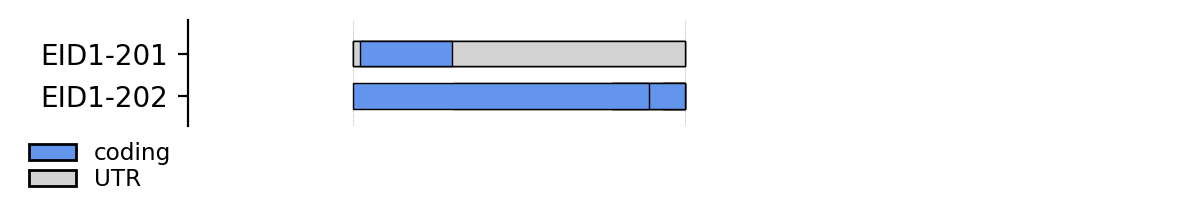

In [24]:
gene = 'EID1'
iso_numbers = ['201', '202']


transcript_list = [f"{gene}-{num}" for num in iso_numbers]

transcripts, exons, cds = get_gene_frame(gdf, gene, transcript_list=transcript_list)
    
plot_cds_on_exon(exons, cds,
                 exon_color="lightgrey",
                 cds_color='cornflowerblue',
                 figsize=(len(exons)*2, len(transcripts)*0.6)
                 # figsize=(len(exons)*0.2, len(transcripts)*0.6)
                )